# Reinforcement Learning Tarea 3 - Métodos Monte Carlo (blackjack)

En este laboratorio vamos a explorar los métodos de Monte Carlo (Capítulo 5 del libro de Sutton y Barto). Para esto, vamos a volver a utilizar un ambiente definido en [Gymnasium](https://gymnasium.farama.org/index.html), es el caso esta vez de otro ambiente sencillo: el juego de Blackjack. El [ambiente de gymnasium](https://gymnasium.farama.org/environments/toy_text/blackjack/) esta inspirado por el ejemplo 5.1 del libro, ya esta incluido en gym, por lo que no es necesario crearlo desde cero. 


## Descripción del ambiente a usar

### Reglas del juego

Es un juego de cartas donde el objetivo es obtener cartas que sumen lo más cercano a 21 posible, sin pasarnos. Jugamos contra un dealer fijo unicamente.

Reglas:
   
- Las cartas con figuras (Jotas, Reinas y Reyes) tienen valor de 10.
- Los Ases pueden valer 11 ó 1, cuando vale 11 se lo llama "usable" y es su valor por defecto.
- En este caso jugamos con un mazo infinito (con reemplazo).
- El dealer comienza con una carta boca arriba y una boca abajo.
- El jugador puede pedir una carta (HIT) hasta que decida quedarse (STICK) o exceeda los 21 puntos (BUST).
- Cuando el jugador se queda (STICK), el dealer muestra su carta boca abajo y pide cartas hasta que su suma sea 17 o más.
- Si el dealer se pasa de 21, el jugador gana. En caso contrario, gana quien tenga la suma más cerca de 21.

### Implementación en Gymnasium

- La reward por perder es -1, por ganar es +1 y por pedir carta es 0. En caso de empate, la reward es 0.
- Cada observacion es una tupla que tiene: 
    - la suma del jugador
    - la carta boca arriba del dealer (1-10 donde 1 es un As)
    - True o False si el jugador tiene un As usable o no

Revisa el [ambiente en gymnasium](https://gymnasium.farama.org/environments/toy_text/blackjack/) para entender como funciona.


### A entregar

- Notebook con solución a los algoritmos presentados
- Analisis de la función de valor estimada para distinto número de episodios a visitar (ej: 100, 10000, 50000, 500000). Se busca que puedan demostrar entendimiento del algoritmo y sus resultados (Esperamos gráficas y analisis de las mismas). 
- Estimaciones de función de valor para otras politicas definidas por el estudiante (al menos una). 

In [31]:
import gymnasium as gym
import numpy as np
from collections import defaultdict
from tqdm import tqdm
from Utils import plot_value_distribution, plot_Q_distribution, plot_greedy_policy

In [32]:
NUMBER_EPISODES = 500_000

In [33]:
# Nos asegurams que las gráficas se muestren en el notebook
import matplotlib
%matplotlib inline

 Vemos el espacio de estado y acción del ambiente de blackjack.

In [34]:
# Crear el entorno de Blackjack
env = gym.make("Blackjack-v1", render_mode="rgb_array", sab=True)
print(env.action_space)
print(env.observation_space)

Discrete(2)
Tuple(Discrete(32), Discrete(11), Discrete(2))


In [35]:
# vemos un ejemplo de observación
obs, _ = env.reset()
print(f"Jugador: {obs[0]}, Dealer: {obs[1]}, As usable: {obs[2]} ")

Jugador: 17, Dealer: 8, As usable: 0 


Simulemos una partida de blackjack.

In [36]:
# Caso de prueba
state,_ = env.reset()
print('initial state:', state)

while True:
    action = env.action_space.sample()
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print('state:', state, 'reward:', reward, 'done:', done)
    if done or truncated:
        print(f'Reward: {reward}')                
        break

initial state: (13, 5, 0)
state: (13, 5, 0) reward: -1.0 done: True
Reward: -1.0


## Predicción de la función de valor ($V$ y $Q$)

Vamos a implementar el algoritmo de Monte Carlo para estimar las funciones de valor $V$ y $Q$ para el ambiente de blackjack asi como algunas variantes (first visit, every visit, exploración inicial, etc).

Para ello primero vamos a definir una politica: Si suma 20 o más, se queda (STICK), si no pide carta (HIT). Esta política es la que se usa en el ejemplo del libro.

In [37]:
STICK = 0
HIT = 1
       
## Politica Sutton & Barto
def sutton_policy(observation):
    player_sum, _, _ = observation
    return STICK if player_sum >= 20 else HIT

### Generación de episodios

Vamos a implementar una función que genere episodios de la política definida. La función va a recibir el ambiente y la política y va a devolver una lista de transiciones (estado, acción, reward, next_state).

In [38]:
def generate_episode(policy, env):
    """
    Genera un episodio utilizando la política dada.
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno de OpenAI Gym.
    Returns:
        episode: Lista de tuplas (estado, acción, recompensa, siguiente_estado).
    """
    episode = []
    state, _ = env.reset()
    done = False

    while not done:
        action = policy(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        episode.append((state, action, reward, next_state))
        state = next_state
        done = terminated or truncated

    return episode

In [39]:
# lo probamos
episode = generate_episode(sutton_policy, env)
print("Episodio generado:")
for state, action, reward, next_state in episode:
    print(f"Estado: {state}, Acción: {action} ({'Hit' if action == 1 else 'Stick'}), Recompensa: {reward}, Siguiente estado: {next_state}")

Episodio generado:
Estado: (14, 4, 0), Acción: 1 (Hit), Recompensa: -1.0, Siguiente estado: (24, 4, 0)


### First-Visit MC para estimar $V$

El primer algoritmo que vamos a implementar es el de Monte Carlo First Visit. Este algoritmo estima la función de valor $V$ para una política dada.

$$
\begin{aligned}
\textbf{Algoritmo First-Visit MC (para estimar }v_\pi\text{):} \\[6pt]
\textbf{Entrada:} & \quad \pi,\ \text{política a evaluar.}\\
& \quad \text{(Se asume que podemos generar episodios con } \pi\text{.)}\\[6pt]
\textbf{Inicializar:} 
& \quad V(s) \in \mathbb{R}, \quad \forall\, s \in S \quad (\text{valores arbitrarios})\\
& \quad \text{Returns}(s) \leftarrow \varnothing, \quad \forall\, s \in S.\\[6pt]
\textbf{Bucle (por cada episodio):} 
& \\[-2pt]
& \quad \text{Generar un episodio siguiendo } \pi: (S_0, A_0, R_1, \ldots, S_T).\\
& \quad G \leftarrow 0.\\
& \quad \textbf{para } t = T-1,\, T-2,\, \ldots,\, 0:\\
& \quad\quad G \leftarrow \gamma\,G + R_{t+1}.\\
& \quad\quad \textbf{si } S_t \notin \{S_0, S_1, \ldots, S_{t-1}\}:\\
& \quad\quad\quad \text{Returns}(S_t) \leftarrow \text{Returns}(S_t) \cup \{G\}.\\
& \quad\quad\quad V(S_t) \leftarrow \text{average}\bigl(\text{Returns}(S_t)\bigr).\\[6pt]
\textbf{Retornar:} 
& \quad V.
\end{aligned}
$$

> Tip: con [defaultdict](https://docs.python.org/3/library/collections.html#defaultdict-objects) podemos definir un diccionario con un valor por defecto.

In [40]:
A = defaultdict(float)
B = defaultdict(int)
C = defaultdict(lambda: [])

print(A[999])
print(B[999])
print(C[999])

0.0
0
[]


In [41]:
for i in range(10, -1, -1):
    print(i)

10
9
8
7
6
5
4
3
2
1
0


In [52]:
from email.policy import default

from numpy import number


def first_visit_mc_prediction(policy, env, number_episodes=NUMBER_EPISODES, gamma=1.0):
    """
    Estima V_pi usando el método de Monte Carlo First-Visit.
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno de OpenAI Gym.
        number_episodes: Cantidad de episodios a generar.
        gamma: Factor de descuento.
    Returns:
        V: defaultdict que mapea estado -> valor estimado V(s).
    """
    
    V = defaultdict(float)
    #returns = defaultdict(lambda: [])
    N = defaultdict(int)
    for _ in tqdm(range(number_episodes)):
        episodio = generate_episode(policy, env)
        state = [s for (s,_,_,_) in episodio]
        G = 0
        T = len(episodio)
        for t in range(T-1, -1, -1):
            s, a, r, s_next = episodio[t] #state, action, reward, state_next
            G = gamma * G + r
            if s not in state[:t]:
                #returns[s].append(G)
                #V[s] = sum(returns[s]) / len(returns[s])
                N[s] += 1
                V[s] += (G - V[s]) / N[s]
    return V
    
    #raise NotImplementedError("Implementar First-Visit MC para estimar V")

In [53]:
sab_value = first_visit_mc_prediction(sutton_policy, env)

100%|██████████| 500000/500000 [00:20<00:00, 24797.43it/s]


In [54]:
print(sab_value)

defaultdict(<class 'float'>, {(16, 2, 0): -0.6561889886762972, (8, 2, 0): -0.5350584307178632, (18, 10, 0): -0.7250478534317732, (20, 10, 0): 0.440260083173807, (21, 9, 0): 0.9395560310243389, (13, 9, 0): -0.5577663671373546, (18, 9, 0): -0.7143119603160057, (13, 9, 1): -0.23232323232323232, (21, 5, 1): 0.9755154639175254, (17, 10, 0): -0.7010333712552085, (19, 2, 0): -0.7373523708796066, (12, 10, 0): -0.5775636383891289, (20, 3, 0): 0.6307277628032331, (12, 3, 0): -0.5505072783414225, (13, 3, 1): -0.3382663847780131, (20, 5, 0): 0.6541313559322028, (20, 10, 1): 0.4130138851075413, (9, 10, 0): -0.5498078155028837, (16, 1, 0): -0.7485725536522934, (11, 1, 0): -0.25394614670380666, (9, 1, 0): -0.6172436316133241, (14, 10, 0): -0.6180569894693422, (14, 10, 1): -0.3659033078880405, (20, 7, 1): 0.7442371020856209, (12, 2, 0): -0.5432982770194665, (6, 2, 0): -0.5278514588859415, (16, 6, 0): -0.6578947368421041, (11, 6, 0): -0.0317115551694179, (16, 9, 0): -0.6360116166505342, (21, 10, 0): 0.

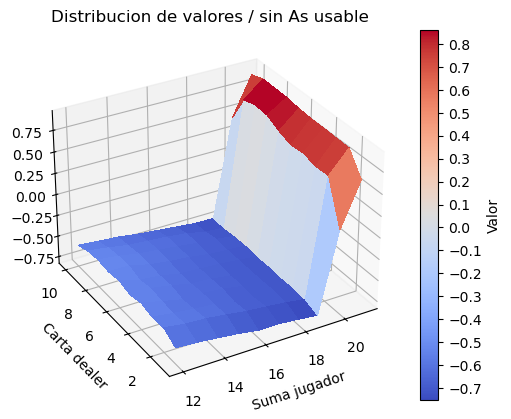

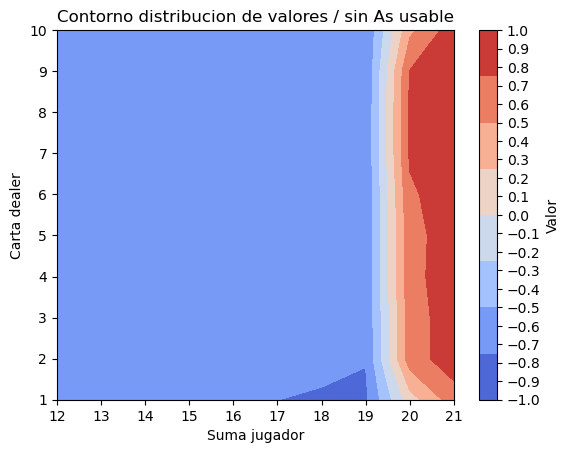

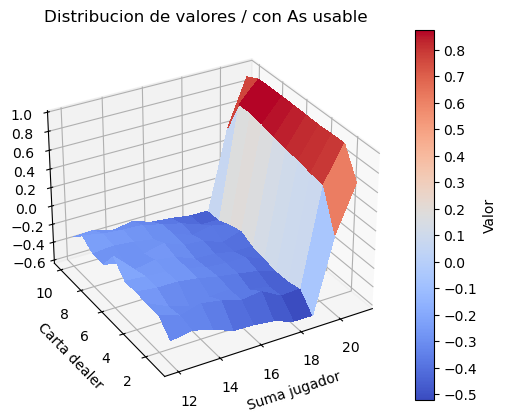

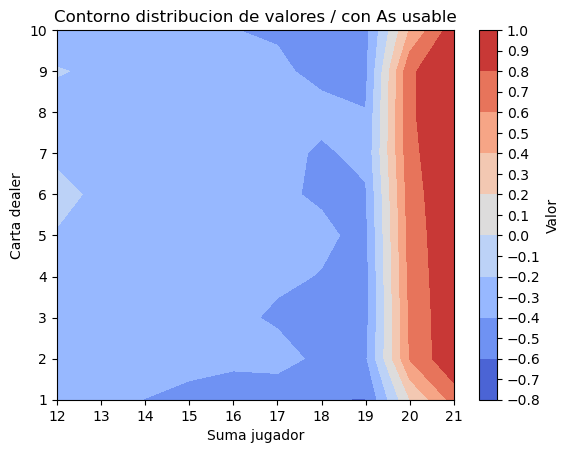

In [55]:
plot_value_distribution(sab_value)

### Convergencia y número de episodios

Por la **ley de los grandes números**, $V(s) \to v_\pi(s)$ cuando el número de visitas a $s$ tiende a infinito. Pero ¿cuántos episodios necesitamos en la práctica?

Una buena forma de inspeccionar la convergencia es comparar la estimación con distintos presupuestos de episodios y observar:
1. **Suavidad** del surface plot (con pocos episodios suele verse muy ruidoso, sobre todo en las regiones con As usable que se visitan menos).
2. **Trayectoria de un estado fijo**, por ejemplo $V((20,5,0))$: graficar su valor estimado vs. el número de episodios y ver cómo decrece la varianza.

Sugerencia para la Tarea 2:
```python
for n in [100, 10_000, 50_000, 500_000]:
    V_n = first_visit_mc_prediction(sutton_policy, env, number_episodes=n)
    plot_value_distribution(V_n)
```
Y/o medir el error contra una estimación de referencia (por ejemplo, $V$ con 1M de episodios).

Una estrategía más elaborada, basada en Edward Thorp, que se basa en la carta del dealer y la suma del jugador. La idea es que si el dealer tiene una carta baja (2-6) el jugador se queda si tiene 12 o más, si no pide carta. Si el dealer tiene una carta alta (7-10) el jugador se queda si tiene 17 o más, si no pide carta.

100%|██████████| 500000/500000 [00:18<00:00, 27425.22it/s]


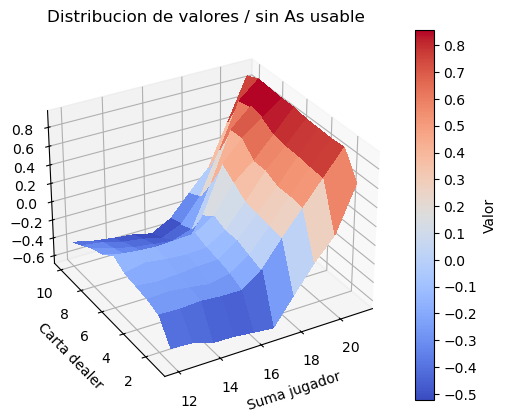

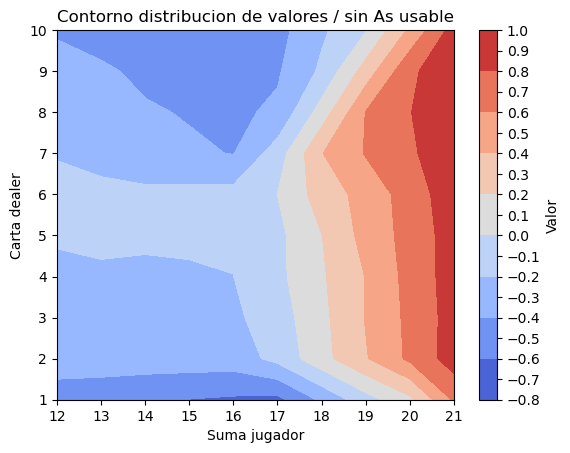

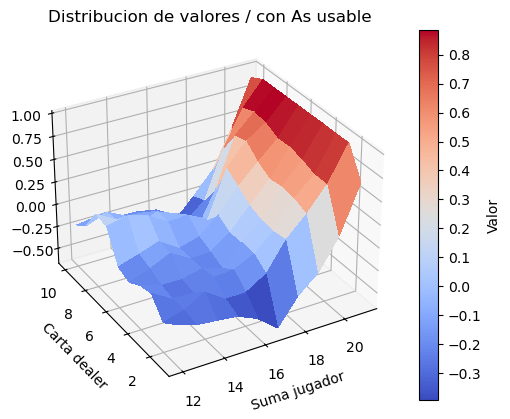

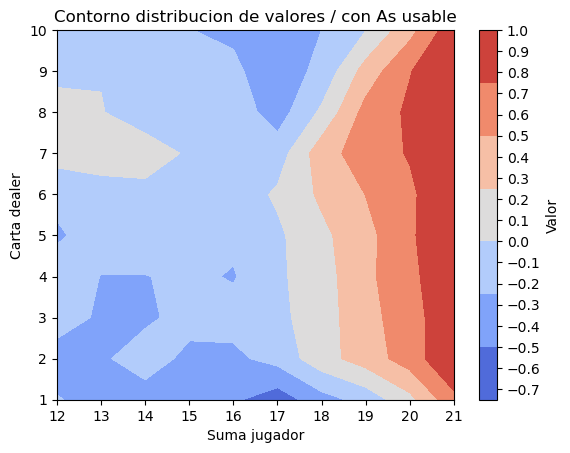

In [56]:
def thorp_policy(observation):
    player_sum, dealer_card, usable_ace = observation
    # Si la suma del jugador es menor a 12, nunca se pasa, así que se pide carta.
    if player_sum < 12:
        return HIT
    # Para sumas entre 12 y 16, se aconseja quedarse si el dealer muestra una carta débil (2 a 6),
    # ya que el dealer tiene más probabilidad de pasarse.
    if 12 <= player_sum <= 16:
        if 2 <= dealer_card <= 6:
            return STICK
        else:
            return HIT
    # Con una suma de 17 o mayor, es recomendable plantarse.
    return STICK

thorp_value = first_visit_mc_prediction(thorp_policy, env)

plot_value_distribution(thorp_value)

> 1) ¿Qué valores se esperan de $V$ si implementamos el algoritmo de Monte Carlo Every Visit en este caso? ¿Por qué?
> 2) Definir una política diferente que tenga en cuenta el As usable y estimar su función de valor. 

### First-Visit MC para estimar $Q$ con exploración inicial

Cuando queremos estimar la función de valor $Q$ para una política dada, tenemos el problema de que no tenemos una política exploratoria. Por ende podría no visitar todos los estados y acciones. Para resolver esto, podemos usar la técnica de exploración inicial donde se elige un estado aleatorio ($S_0$) y una acción aleatoria ($A_0$) y se juega un episodio desde ahí. Esto nos permite explorar el espacio de estados y acciones. 

> Notar que la política no cambia, solo se elige un estado y acción aleatorios para empezar a jugar.

> El desafío en Gymnasium es que no podemos elegir el estado inicial. Pero podemos intentar "hacer trampa" y modificar su estado interno. Esto no es recomendable, pero para fines de este laboratorio lo vamos a hacer.


$$
\begin{aligned}
\textbf{Algoritmo First-Visit MC (para estimar }Q(s,a)\text{ con exploración inicial):} \\[6pt]
\textbf{Entrada:} & \quad \pi,\ \text{la política a evaluar.}\\[6pt]
\textbf{Inicializar:} & \quad Q(s,a) \in \mathbb{R}\quad \text{(valores arbitrarios)},\quad \forall\, s \in S,\; a \in A(s),\\
& \quad \text{Returns}(s,a) \leftarrow \varnothing,\quad \forall\, s \in S,\; a \in A(s).\\[6pt]
\textbf{Loop (por cada episodio):} & \\[-2pt]
& \quad \text{Elegir al azar un estado inicial } S_0 \in S \text{ y una acción } A_0 \in A(S_0).\\
& \quad \text{Generar un episodio siguiendo } \pi: (S_0, A_0, R_1, S_1, A_1, \ldots, S_T).\\
& \quad G \leftarrow 0.\\
& \quad \textbf{para } t = T-1,\; T-2,\; \ldots,\; 0: \\
& \quad\quad G \leftarrow \gamma\,G + R_{t+1}.\\
& \quad\quad \textbf{si } (S_t,A_t) \notin \{(S_0,A_0),\,(S_1,A_1),\,\ldots,\,(S_{t-1},A_{t-1})\}: \\
& \quad\quad\quad \text{Returns}(S_t,A_t) \leftarrow \text{Returns}(S_t,A_t) \cup \{G\}.\\
& \quad\quad\quad Q(S_t,A_t) \leftarrow \text{average}\Bigl(\text{Returns}(S_t,A_t)\Bigr).\\[6pt]
\textbf{Retornar:} & \quad Q.
\end{aligned}
$$


In [57]:
from gymnasium.envs.toy_text.blackjack import BlackjackEnv

# https://github.com/Farama-Foundation/Gymnasium/blob/main/gymnasium/envs/toy_text/blackjack.py
# https://gymnasium.farama.org/api/wrappers/#gymnasium.Wrapper
class BlackjackEnvWrapper(BlackjackEnv):
    def set_state(self, state):
        """
        Fija el estado inicial deseado.
        state: (player_sum, dealer_card, usable_ace)

        Nota: para algunas combinaciones (por ejemplo player_sum=21 sin As usable)
        no es posible construir la mano con sólo 2 cartas. En esos casos la mano
        se aproxima y `_get_obs()` devolverá la observación real (que puede no
        coincidir exactamente con la solicitada).
        """
        player_sum, dealer_card, usable = state
        # Configuramos la mano del jugador
        if usable:
            # Para tener un as usable, construimos una mano que contenga un 1 y otra carta que
            # haga que la suma (1 + otra carta + 10) sea player_sum.
            card = player_sum - 11
            # Aseguramos que la otra carta esté en el rango permitido (1 a 10)
            card = max(1, min(card, 10))
            self.player = [1, card]
        else:
            # Sin as usable, buscamos dos cartas que sumen player_sum
            card1 = player_sum // 2
            card2 = player_sum - card1
            card1 = max(2, min(card1, 10))
            card2 = max(2, min(card2, 10))
            self.player = [card1, card2]

        # Configuramos la mano del dealer de modo que su carta visible sea la deseada.
        # Usamos self.np_random (heredado de BlackjackEnv) para que el seed del entorno
        # controle la carta oculta y los resultados sean reproducibles.
        self.dealer = [dealer_card, int(self.np_random.integers(1, 11))]


In [66]:
#from nt import truncate

def generate_episode_with_initial_exploration(policy, env):
    """
    Genera un episodio utilizando la política dada, con exploración inicial:
    se elige (S_0, A_0) al azar y luego se sigue la política.
    """
    episode = []
    env.reset()

    # Escogemos un estado inicial aleatorio.
    # Nota: ignoramos sumas < 12 porque cualquier política razonable siempre pide
    # carta (HIT) en esos estados (no es posible "pasarse" todavía).
    player_sum = np.random.randint(12, 22)   # suma entre 12 y 21
    dealer_card = np.random.randint(1, 11)   # carta del dealer entre 1 y 10
    usable = np.random.randint(0, 2)         # 0 o 1
    state = (player_sum, dealer_card, usable)

    # Usamos el método del wrapper para fijar el estado
    env.set_state(state)
    state = env._get_obs()

    is_first_action = True
    done = False
    episode = []
    while not done:
        if is_first_action: 
            action = env.action_space.sample() # solo la primera vez que tomo una accion al azar
            is_first_action = False
        else:
            action = policy(state)

        next_state, reward, truncated, terminated, _ = env.step(action)
        done = terminated or truncated 
        episode.append((state, action, reward, next_state))
        state = next_state
    return episode

#    raise NotImplementedError("Implementar el bucle: primer paso con acción aleatoria, luego seguir la política")


In [69]:
env_wrapped = BlackjackEnvWrapper(env)
generate_episode_with_initial_exploration(thorp_policy, env_wrapped)

[((14, 1, 1), np.int64(1), 0.0, (16, 1, 1)),
 ((16, 1, 1), 1, 0.0, (21, 1, 1)),
 ((21, 1, 1), 0, 1.0, (21, 1, 1))]

In [72]:
def first_visit_mc_q_prediction_ie(policy, env, number_episodes=NUMBER_EPISODES, gamma=1.0):
    """
    Estima Q_pi usando First-Visit MC con exploración inicial (Exploring Starts).
    Args:
        policy: Función que toma un estado y devuelve una acción.
        env: Entorno (BlackjackEnvWrapper) que permite fijar el estado inicial.
        number_episodes: Cantidad de episodios a generar.
        gamma: Factor de descuento.
    Returns:
        Q: defaultdict que mapea (estado, acción) -> valor estimado Q(s, a).
    """
    
    Q = defaultdict(float)
    N = defaultdict(int)
    
    for _ in tqdm(range(number_episodes)):
        episode = generate_episode_with_initial_exploration(policy, env)
        sa = [(s,a) for s,a,_,_ in episode]
        G = 0
        T = len(episode)
        for t in range(T-1, -1, -1):
            state, action, reward, next_state = episode[t]
            G = gamma * G + reward
            if (state, action) not in sa[:t]: # si no está ese estado antes (cronologicamente)
                N[(state, action)] += 1
                Q[(state, action)] += (G - Q[(state, action)]) / N[(state, action)]
    return Q
    
    #raise NotImplementedError("Implementar First-Visit MC con Exploring Starts para estimar Q")

In [73]:
sab_q_value = first_visit_mc_q_prediction_ie(sutton_policy, env_wrapped)

100%|██████████| 500000/500000 [00:23<00:00, 21007.20it/s]


In [74]:
sab_q_value[(21, 5, 0), 0]

0.8791334093500572

In [75]:
sab_q_value[(21, 5, 0), 1] # Por que da esto?

0.0

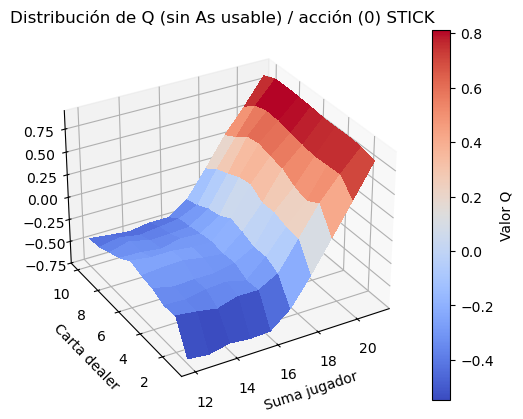

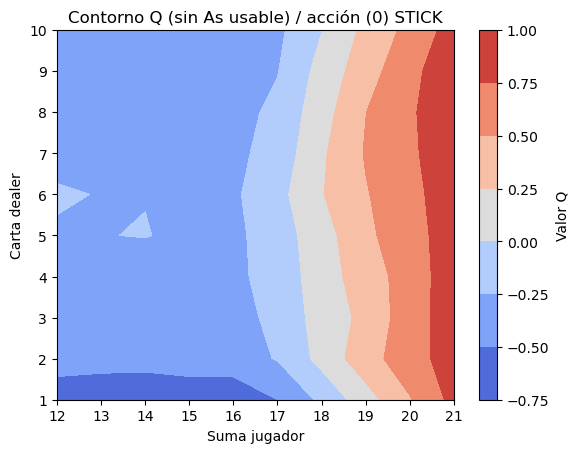

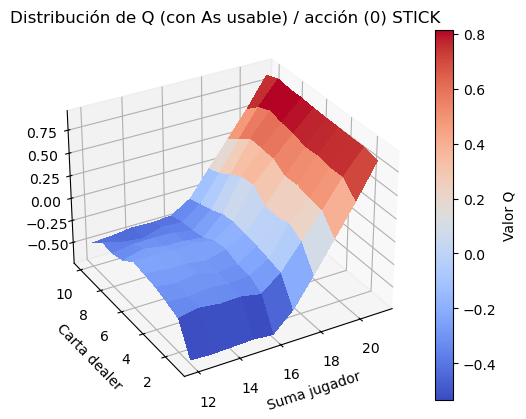

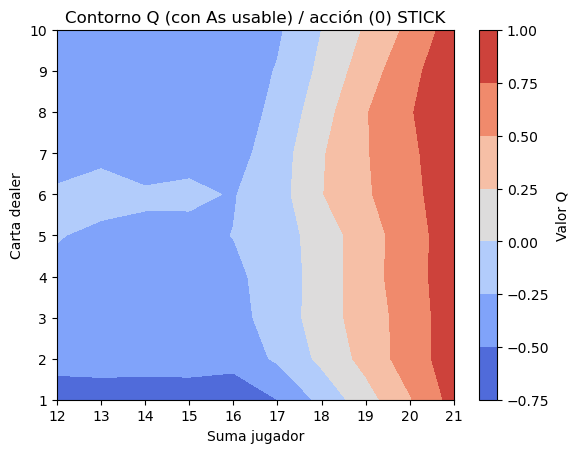

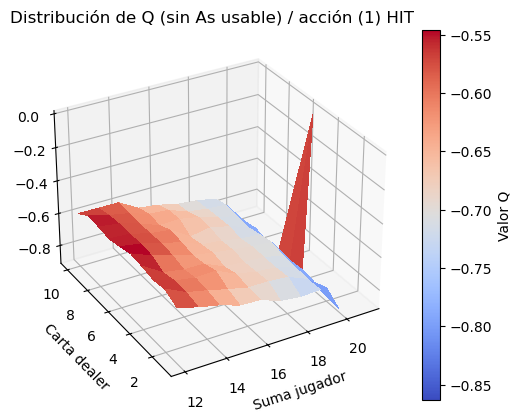

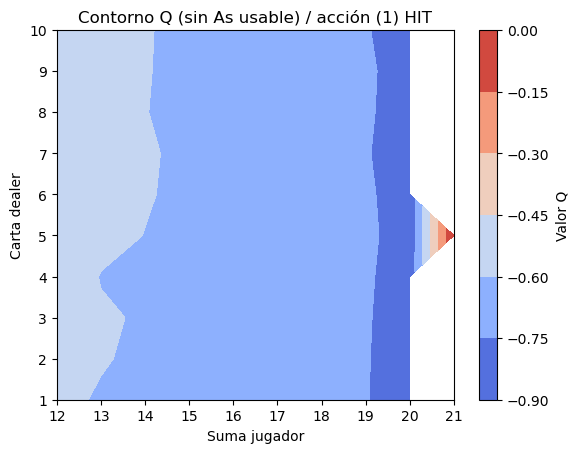

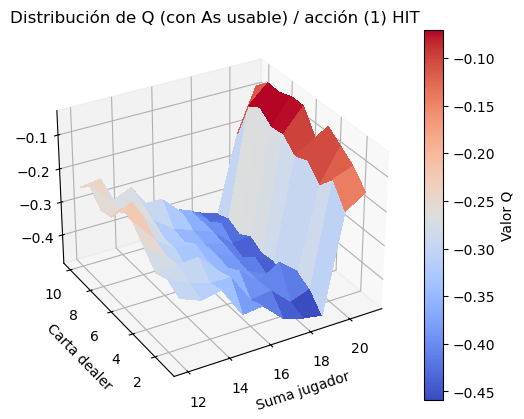

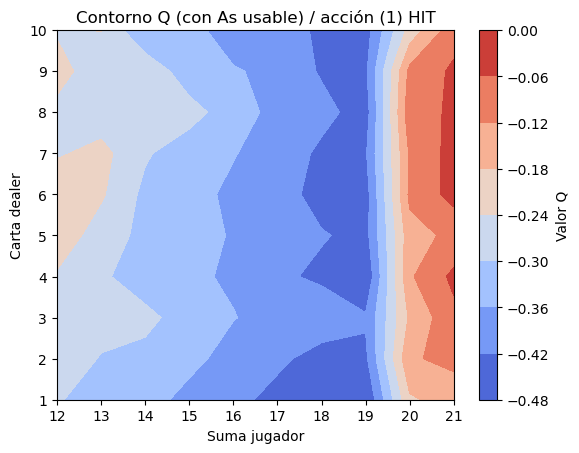

In [76]:
plot_Q_distribution(sab_q_value)

100%|██████████| 500000/500000 [00:23<00:00, 21637.47it/s]


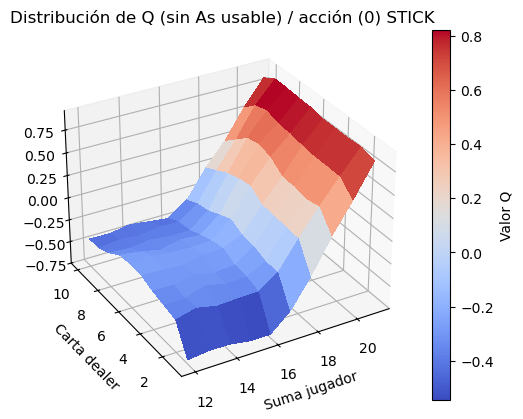

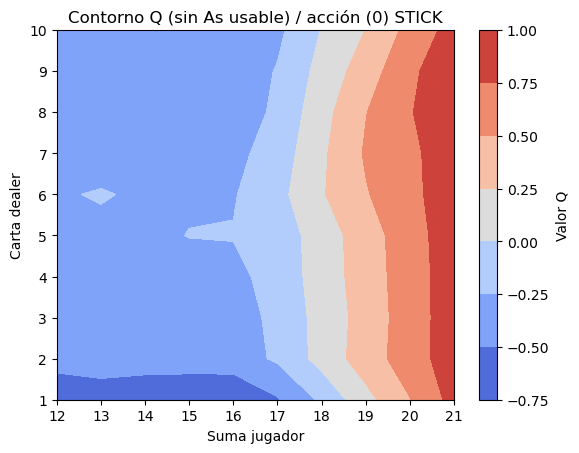

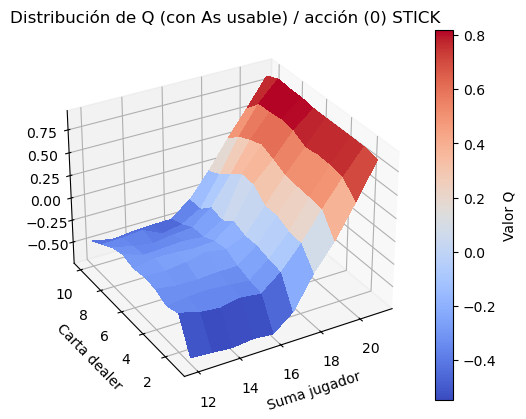

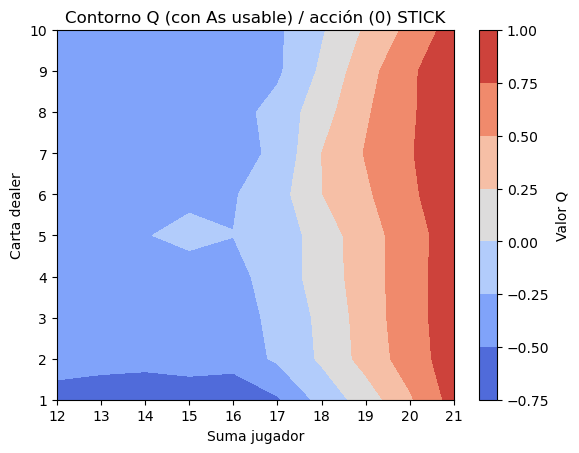

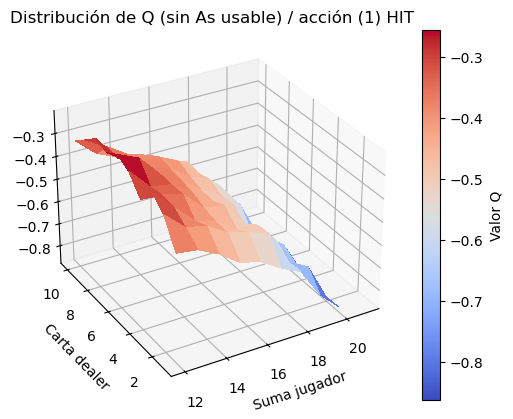

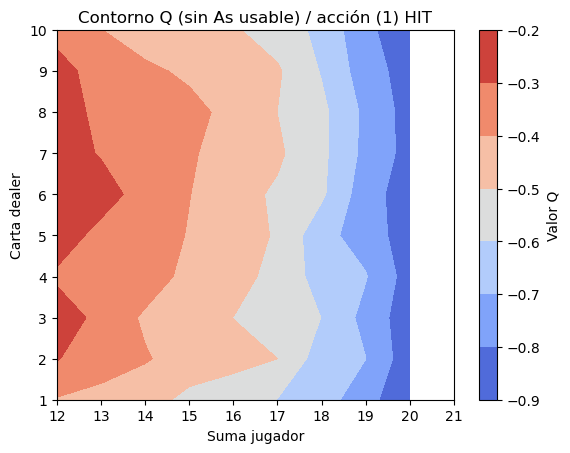

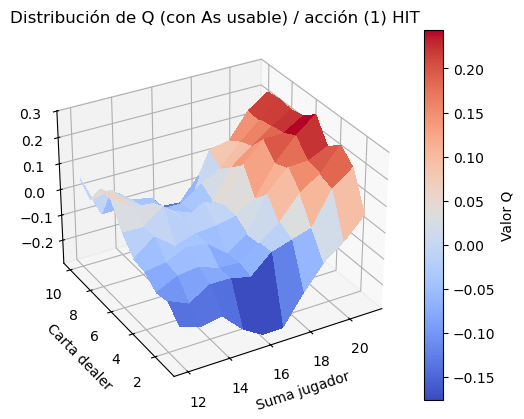

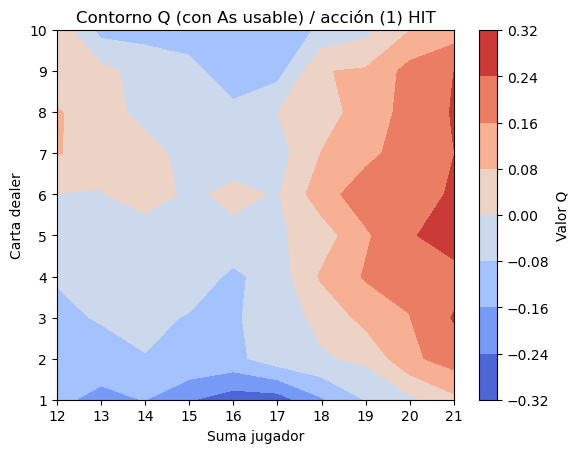

In [77]:
thorp_q_value = first_visit_mc_q_prediction_ie(thorp_policy, env_wrapped)
plot_Q_distribution(thorp_q_value)

## **Tareas**

1. Implementar el algoritmo de Monte Carlo First Visit para estimar la función de valor $V$ y $Q$ para la política definida.
2. Comparar las estimaciones de la función de valor para distintos episodios (ej: 100, 10000, 50000, 500000). 
3. Elaborar una política diferente que tenga en cuenta el As usable y estimar su función de valor.
4. [extra] Implementar el algoritmo un algoritmo de control Monte Carlo para estimar la politica óptima. Puede ser MC ES para control (cap 5.3 del libro) o on-policy MC control (cap 5.4 del libro). Graficar resultados y comparar con politicas anteriores. ¿ Puede asegurar que "la casa siempre gana" ? 🎰

## Control: Monte Carlo con Exploring Starts (MC ES) [extra]

Hasta ahora **evaluamos** políticas dadas (predicción). Con MC ES, además de estimar $Q$, vamos a **mejorar** la política iterativamente, alternando *evaluation* (con un único episodio) y *greedy improvement*.

$$
\begin{aligned}
\textbf{Algoritmo Monte Carlo Exploring Starts (Sutton \& Barto, 5.3):} \\[6pt]
\textbf{Inicializar:} & \quad \pi(s) \in A(s)\ \text{arbitrario},\ \forall s \in S, \\
& \quad Q(s,a) \in \mathbb{R}\ \text{arbitrario},\ \forall s \in S,\ a \in A(s), \\
& \quad \text{Returns}(s,a) \leftarrow \varnothing. \\[6pt]
\textbf{Loop (por cada episodio):} & \\[-2pt]
& \quad \text{Elegir } S_0 \in S,\ A_0 \in A(S_0)\ \text{al azar (todos con prob. > 0).} \\
& \quad \text{Generar episodio siguiendo } \pi: (S_0, A_0, R_1, \ldots, S_T). \\
& \quad G \leftarrow 0. \\
& \quad \textbf{para } t = T-1, \ldots, 0: \\
& \quad\quad G \leftarrow \gamma G + R_{t+1}. \\
& \quad\quad \textbf{si } (S_t, A_t) \notin \{(S_0,A_0),\ldots,(S_{t-1},A_{t-1})\}: \\
& \quad\quad\quad \text{Returns}(S_t,A_t) \leftarrow \text{Returns}(S_t,A_t) \cup \{G\}. \\
& \quad\quad\quad Q(S_t, A_t) \leftarrow \text{average}(\text{Returns}(S_t,A_t)). \\
& \quad\quad\quad \pi(S_t) \leftarrow \arg\max_a Q(S_t, a). \\[6pt]
\textbf{Retornar:} & \quad \pi,\ Q.
\end{aligned}
$$

> **Diferencia clave con la predicción:** la política se actualiza dentro del loop ($\pi(S_t) \leftarrow \arg\max_a Q$). Como $\pi$ cambia constantemente, no podemos pasarla como parámetro fijo: la mantenemos en un diccionario que el algoritmo modifica.

In [ ]:
def mc_es_control(env, number_episodes, gamma=1.0):
    """
    Monte Carlo Exploring Starts para control (Sutton & Barto, 5.3).
    Aprende simultáneamente Q y la política greedy óptima.

    Args:
        env: BlackjackEnvWrapper (debe permitir set_state).
        number_episodes: cantidad de episodios.
        gamma: factor de descuento.

    Returns:
        Q: defaultdict {(estado, acción): valor estimado}.
        pi: dict {estado: acción greedy}.

    Tip: definir una sub-función `current_policy(state)` que consulte `pi`
    con un fallback (ej. STICK) y pasarla a `generate_episode_with_initial_exploration`.
    """
    raise NotImplementedError("Implementar Monte Carlo Exploring Starts para control")

In [ ]:
Q_star, pi_star = mc_es_control(env_wrapped, number_episodes=500_000)
plot_greedy_policy(Q_star, title_suffix="(MC ES)")

> Comparar `pi_star` con la política de Sutton (STICK >= 20) y con la de Thorp. ¿En qué celdas difieren? ¿La política aprendida coincide con la de la Figura 5.2 del libro?